In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\fintech-review-analytics')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print("Libraries loaded!")

Libraries loaded!


In [2]:
df = pd.read_csv('data/raw/reviews_clean.csv')
print(f"Loaded {len(df):,} reviews")
print(f"Banks: {df['bank'].unique()}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 1,797 reviews
Banks: <ArrowStringArray>
['CBE', 'BOA', 'Dashen']
Length: 3, dtype: str
Columns: ['review', 'rating', 'date', 'bank', 'source']


,review,rating,date,bank,source
0,pels,5,2026-05-18,CBE,Google Play
1,What an excellent app with smooth performance !!,5,2026-05-18,CBE,Google Play
2,በጣም ጥሩ ነው እነማሰግነለን,5,2026-05-18,CBE,Google Play
3,svabst keessatti argamu yoo ta'u yeroo ammaa k...,5,2026-05-18,CBE,Google Play
4,nays,5,2026-05-17,CBE,Google Play


## 1. Sentiment Analysis
### Tool Selection: VADER
VADER is chosen because:
- Designed for short social-media style text — ideal for app reviews
- Handles punctuation emphasis (!!!) and capitalization
- No training required — works out of the box
- Fast enough to process 1,797 reviews in seconds
- Produces compound score from -1 (most negative) to +1 (most positive)

In [3]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    try:
        score = analyzer.polarity_scores(str(text))['compound']
        return score
    except:
        return 0.0

def get_label(score):
    if score >= 0.05:   return 'Positive'
    elif score <= -0.05: return 'Negative'
    else:                return 'Neutral'

# Apply to all reviews
df['sentiment_score'] = df['review'].apply(get_sentiment)
df['sentiment_label'] = df['sentiment_score'].apply(get_label)

print("=== Sentiment Distribution ===")
print(df['sentiment_label'].value_counts())
print(f"\nSentiment assigned to: {df['sentiment_score'].notna().sum():,} reviews (100%)")
df[['review','rating','sentiment_score','sentiment_label']].head(10)

=== Sentiment Distribution ===
sentiment_label
Positive    1096
Neutral      446
Negative     255
Name: count, dtype: int64

Sentiment assigned to: 1,797 reviews (100%)


,review,rating,sentiment_score,sentiment_label
0,pels,5,0.0000,Neutral
1,What an excellent app with smooth performance !!,5,0.6467,Positive
2,በጣም ጥሩ ነው እነማሰግነለን,5,0.0000,Neutral
3,svabst keessatti argamu yoo ta'u yeroo ammaa k...,5,0.0000,Neutral
4,nays,5,0.0000,Neutral
5,very very good 👍 thanks commercial bank of eth...,5,0.8470,Positive
6,so nice,5,0.4754,Positive
7,fantastic,5,0.5574,Positive
8,very nice,5,0.4754,Positive
9,f*k,1,0.0000,Neutral


In [4]:
print("=== Sentiment by Bank ===")
sentiment_bank = df.groupby(['bank','sentiment_label']).size().unstack(fill_value=0)
sentiment_bank['Total'] = sentiment_bank.sum(axis=1)
sentiment_bank_pct = sentiment_bank.div(sentiment_bank['Total'], axis=0).drop('Total', axis=1) * 100
print(sentiment_bank_pct.round(1))

print("\n=== Average Sentiment Score by Bank ===")
print(df.groupby('bank')['sentiment_score'].agg(['mean','median','std']).round(3))

=== Sentiment by Bank ===
sentiment_label  Negative  Neutral  Positive
bank                                        
BOA                  18.0     30.0      52.0
CBE                  10.5     23.7      65.8
Dashen               14.1     20.8      65.2

=== Average Sentiment Score by Bank ===
         mean  median    std
bank                        
BOA     0.179   0.238  0.424
CBE     0.283   0.436  0.360
Dashen  0.299   0.440  0.427


In [5]:
print("=== Average Sentiment Score by Star Rating ===")
rating_sentiment = df.groupby('rating')['sentiment_score'].agg(['mean','count']).round(3)
rating_sentiment.columns = ['Avg Sentiment','Count']
print(rating_sentiment)

=== Average Sentiment Score by Star Rating ===
        Avg Sentiment  Count
rating                      
1              -0.143    389
2               0.057     62
3               0.138     98
4               0.302    133
5               0.407   1115


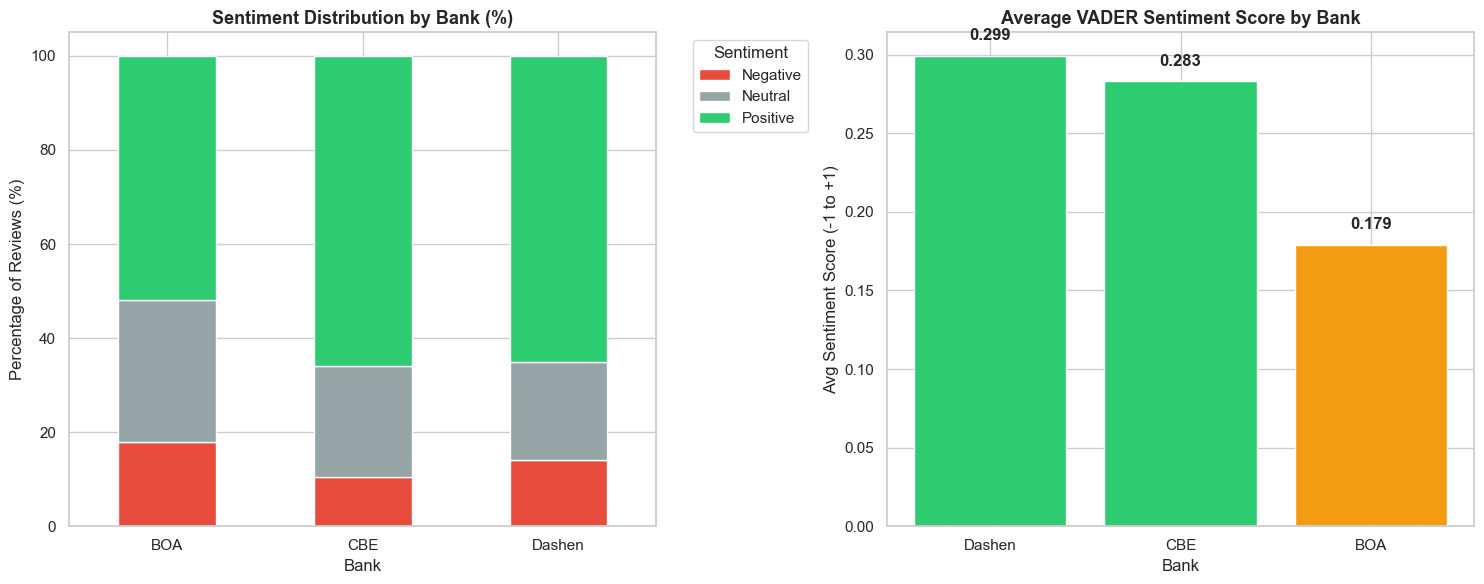

Plot saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Stacked bar chart — sentiment by bank
colors = {'Positive':'#2ecc71', 'Neutral':'#95a5a6', 'Negative':'#e74c3c'}
sentiment_bank_pct[['Negative','Neutral','Positive']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[colors['Negative'], colors['Neutral'], colors['Positive']],
    edgecolor='white'
)
axes[0].set_title('Sentiment Distribution by Bank (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bank')
axes[0].set_ylabel('Percentage of Reviews (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment', bbox_to_anchor=(1.05, 1))

# Average sentiment score by bank
avg_scores = df.groupby('bank')['sentiment_score'].mean().sort_values(ascending=False)
bar_colors = ['#2ecc71' if s > 0.2 else '#f39c12' if s > 0 else '#e74c3c' 
              for s in avg_scores.values]
axes[1].bar(avg_scores.index, avg_scores.values, color=bar_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Average VADER Sentiment Score by Bank', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Bank')
axes[1].set_ylabel('Avg Sentiment Score (-1 to +1)')
for i, (bank, val) in enumerate(avg_scores.items()):
    axes[1].text(i, val+0.01, f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/sentiment_by_bank.png', dpi=150)
plt.show()
print("Plot saved!")

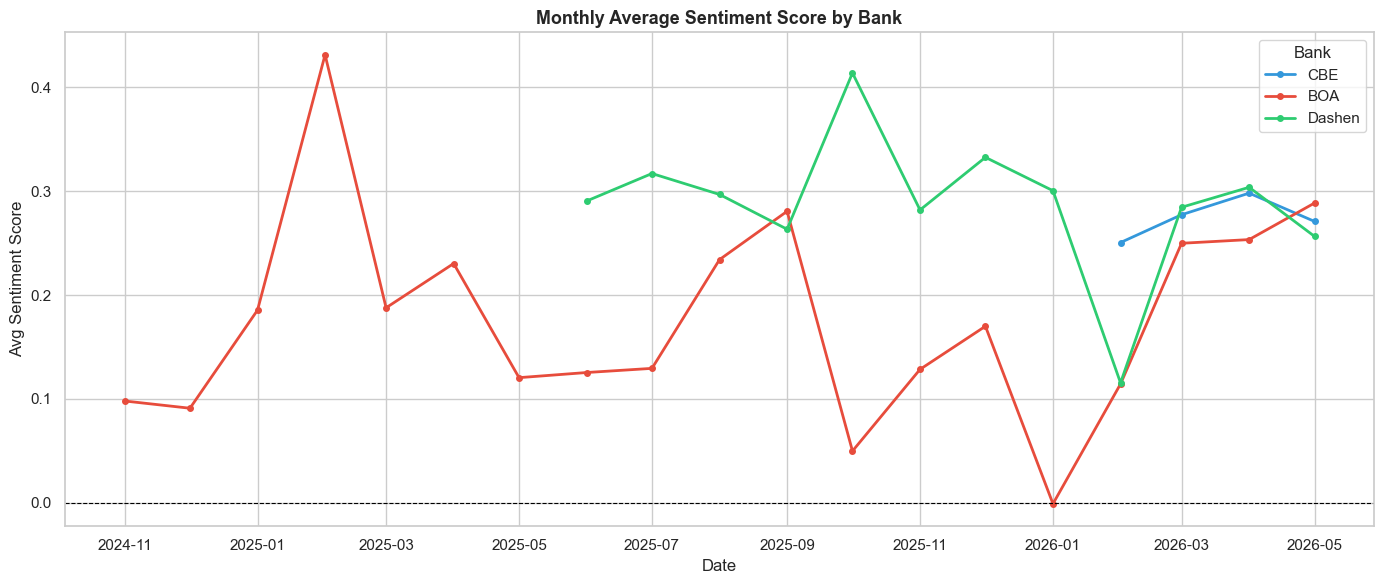

Sentiment trend plot saved!


In [7]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

monthly_sentiment = df.groupby(['bank','month'])['sentiment_score'].mean().reset_index()
monthly_sentiment['month'] = monthly_sentiment['month'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
colors = {'CBE':'#3498db', 'BOA':'#e74c3c', 'Dashen':'#2ecc71'}
for bank in df['bank'].unique():
    data = monthly_sentiment[monthly_sentiment['bank'] == bank]
    plt.plot(data['month'], data['sentiment_score'],
             label=bank, color=colors[bank], linewidth=2, marker='o', markersize=4)

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Monthly Average Sentiment Score by Bank', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Avg Sentiment Score')
plt.legend(title='Bank')
plt.tight_layout()
plt.savefig('notebooks/sentiment_over_time.png', dpi=150)
plt.show()
print("Sentiment trend plot saved!")

## 2. Thematic Analysis
Themes are recurring concepts in user feedback that map to business-relevant issues.
We use TF-IDF to extract keywords then group them into 5 overarching themes per bank.

**Themes defined:**
1. **Transaction Performance** — transfers, slow, loading, payment, failed
2. **Account Access Issues** — login, OTP, password, fingerprint, error
3. **UI & App Design** — interface, design, update, easy, navigation
4. **Customer Support** — support, response, help, service, agent
5. **Feature Requests** — feature, add, need, want, improve, option

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

def clean_text(text):
    """Basic text cleaning for TF-IDF"""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Custom stop words for banking reviews
banking_stopwords = [
    'app', 'bank', 'banking', 'mobile', 'cbe', 'boa', 'dashen',
    'use', 'used', 'using', 'good', 'great', 'nice', 'very',
    'please', 'thank', 'thanks', 'like', 'just', 'really', 'get',
    'also', 'make', 'time', 'one', 'now', 'still', 'even', 'well'
]

def get_top_keywords(df_bank, bank_name, n=30):
    """Extract top TF-IDF keywords for a bank"""
    texts = df_bank['review'].apply(clean_text).tolist()
    
    vectorizer = TfidfVectorizer(
        max_features=100,
        stop_words=banking_stopwords,
        ngram_range=(1, 2),
        min_df=3
    )
    
    X = vectorizer.fit_transform(texts)
    scores = X.toarray().mean(axis=0)
    keywords = pd.Series(scores, index=vectorizer.get_feature_names_out())
    keywords = keywords.sort_values(ascending=False).head(n)
    
    print(f"\n=== Top Keywords: {bank_name} ===")
    print(keywords.head(20).to_string())
    return keywords

# Get keywords per bank
keywords = {}
for bank in df['bank'].unique():
    df_bank = df[df['bank'] == bank]
    keywords[bank] = get_top_keywords(df_bank, bank)


=== Top Keywords: CBE ===
it             0.070829
best           0.053349
the            0.045342
is             0.041542
to             0.041164
and            0.038653
ok             0.036667
for            0.034527
not            0.031726
this           0.027235
application    0.024391
you            0.021199
excellent      0.020451
service        0.019227
my             0.017876
of             0.016613
easy           0.016380
it is          0.015887
work           0.015632
so             0.015570

=== Top Keywords: BOA ===
it             0.074058
the            0.063608
best           0.059150
to             0.045235
is             0.040595
and            0.039284
not            0.030540
this           0.030353
of             0.026095
in             0.025683
my             0.022924
you            0.020570
work           0.018837
ever           0.018590
fast           0.018347
worst          0.017264
on             0.016244
service        0.015270
working        0.015183
applicatio

In [9]:
# Theme keyword mapping
THEME_KEYWORDS = {
    'Transaction Performance': [
        'transfer', 'slow', 'loading', 'payment', 'failed', 'transaction',
        'speed', 'fast', 'quick', 'delay', 'stuck', 'freeze', 'crash',
        'send money', 'transfer money', 'slow loading'
    ],
    'Account Access Issues': [
        'login', 'otp', 'password', 'fingerprint', 'error', 'sign',
        'access', 'locked', 'account', 'verification', 'code', 'cannot login',
        'login error', 'otp not', 'sign in'
    ],
    'UI & App Design': [
        'interface', 'design', 'update', 'easy', 'navigation', 'ui',
        'user friendly', 'simple', 'look', 'layout', 'screen', 'display',
        'smooth', 'convenient', 'excellent'
    ],
    'Customer Support': [
        'support', 'response', 'help', 'service', 'agent', 'customer',
        'call', 'contact', 'solve', 'problem', 'issue', 'complain',
        'customer service', 'no response', 'poor service'
    ],
    'Feature Requests': [
        'feature', 'add', 'need', 'want', 'improve', 'option', 'wish',
        'request', 'budget', 'statement', 'notification', 'history',
        'fingerprint login', 'dark mode', 'english'
    ]
}

def assign_theme(review_text):
    """Assign a theme to a review based on keyword matching"""
    text = str(review_text).lower()
    theme_scores = {}
    
    for theme, keywords in THEME_KEYWORDS.items():
        score = sum(1 for kw in keywords if kw in text)
        theme_scores[theme] = score
    
    best_theme = max(theme_scores, key=theme_scores.get)
    if theme_scores[best_theme] == 0:
        return 'General Feedback'
    return best_theme

df['identified_theme'] = df['review'].apply(assign_theme)

print("=== Theme Distribution ===")
print(df['identified_theme'].value_counts())
print("\n=== Themes per Bank ===")
print(df.groupby(['bank','identified_theme']).size().unstack(fill_value=0))

=== Theme Distribution ===
identified_theme
General Feedback           1246
Transaction Performance     202
UI & App Design             159
Customer Support             77
Account Access Issues        58
Feature Requests             55
Name: count, dtype: int64

=== Themes per Bank ===
identified_theme  Account Access Issues  Customer Support  Feature Requests  \
bank                                                                          
BOA                                  21                28                21   
CBE                                  14                27                12   
Dashen                               23                22                22   

identified_theme  General Feedback  Transaction Performance  UI & App Design  
bank                                                                          
BOA                            425                       70               35  
CBE                            430                       64               53  
D

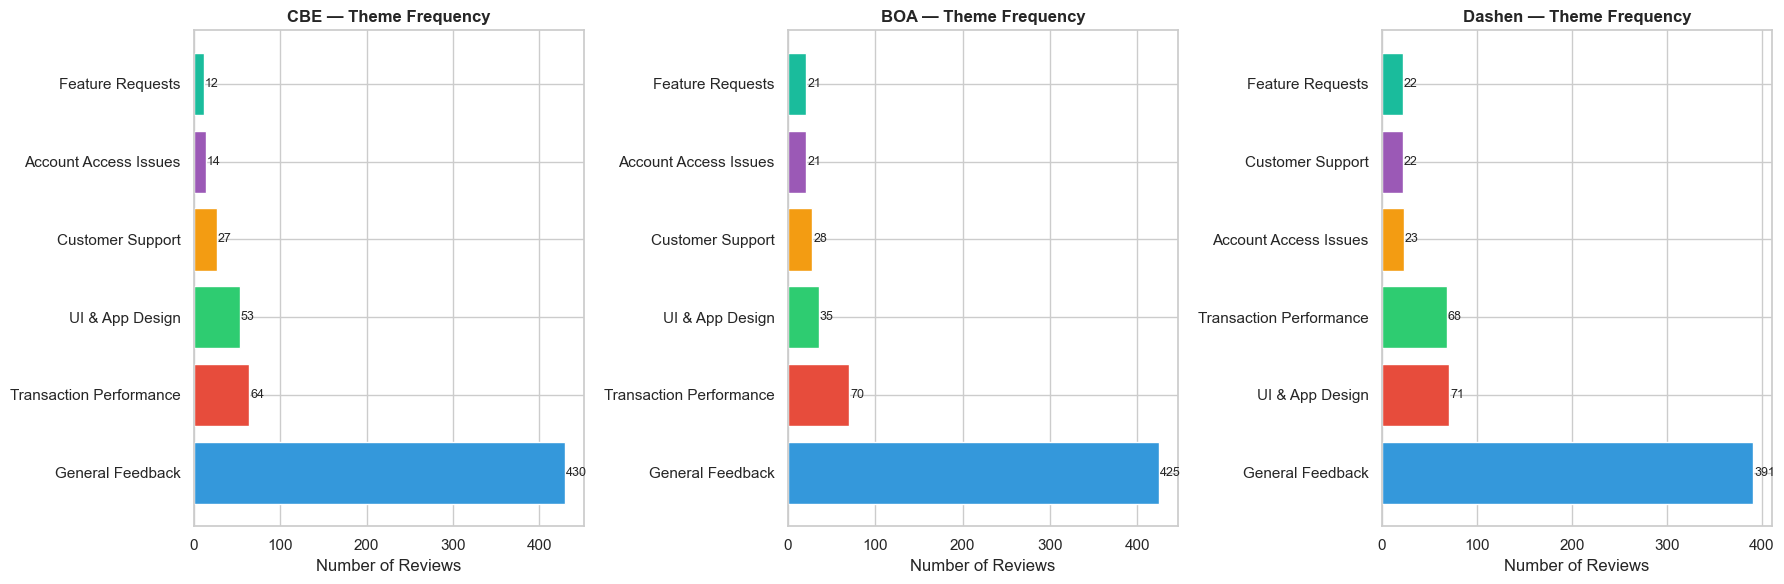

Theme frequency plot saved!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

banks = df['bank'].unique()
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for i, bank in enumerate(banks):
    bank_themes = df[df['bank']==bank]['identified_theme'].value_counts()
    axes[i].barh(bank_themes.index, bank_themes.values,
                 color=colors[:len(bank_themes)], edgecolor='white')
    axes[i].set_title(f'{bank} — Theme Frequency', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Number of Reviews')
    for j, val in enumerate(bank_themes.values):
        axes[i].text(val+1, j, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('notebooks/theme_frequency.png', dpi=150)
plt.show()
print("Theme frequency plot saved!")

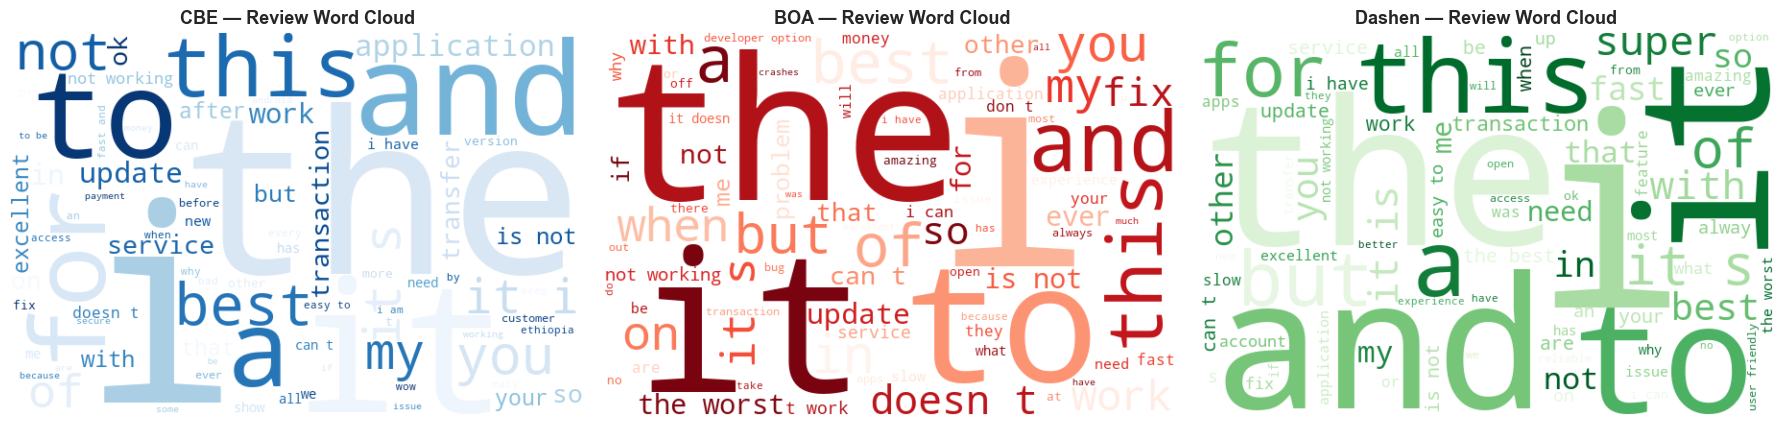

Word clouds saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, bank in enumerate(df['bank'].unique()):
    bank_text = ' '.join(df[df['bank']==bank]['review'].apply(clean_text).tolist())
    
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Blues' if bank=='CBE' else 'Reds' if bank=='BOA' else 'Greens',
        max_words=80,
        stopwords=set(banking_stopwords)
    ).generate(bank_text)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{bank} — Review Word Cloud', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/wordclouds_per_bank.png', dpi=150)
plt.show()
print("Word clouds saved!")

In [12]:
# Save final results with sentiment and themes
output_cols = ['review', 'rating', 'date', 'bank', 'source',
               'sentiment_score', 'sentiment_label', 'identified_theme']

df_final = df[output_cols].copy()
df_final.insert(0, 'review_id', range(1, len(df_final)+1))

df_final.to_csv('data/raw/reviews_with_sentiment.csv', index=False)
print(f"Saved {len(df_final)} reviews with sentiment and themes!")
print(f"\nColumns: {df_final.columns.tolist()}")
df_final.head()

Saved 1797 reviews with sentiment and themes!

Columns: ['review_id', 'review', 'rating', 'date', 'bank', 'source', 'sentiment_score', 'sentiment_label', 'identified_theme']


,review_id,review,rating,date,bank,source,sentiment_score,sentiment_label,identified_theme
0,1,pels,5,2026-05-18,CBE,Google Play,0.0000,Neutral,General Feedback
1,2,What an excellent app with smooth performance !!,5,2026-05-18,CBE,Google Play,0.6467,Positive,UI & App Design
2,3,በጣም ጥሩ ነው እነማሰግነለን,5,2026-05-18,CBE,Google Play,0.0000,Neutral,General Feedback
3,4,svabst keessatti argamu yoo ta'u yeroo ammaa k...,5,2026-05-18,CBE,Google Play,0.0000,Neutral,General Feedback
4,5,nays,5,2026-05-17,CBE,Google Play,0.0000,Neutral,General Feedback
